In [1]:
# =============================================================================
# PHASE 3 — MODELLING: PCA + K-MEANS + GAUSSIAN HMM
# Macro-Market Regime Detection System
# =============================================================================
# Three-step modelling pipeline:
#   Step 1 — PCA: reduce 16 features to k components, visualise separation
#   Step 2 — K-means: independent clustering cross-check, choose k=4
#   Step 3 — Gaussian HMM: primary regime engine, 4 hidden states
#
# Input:  data/processed/us_features_zscored.parquet  (from Phase 2)
# Output: data/processed/us_regime_labels.parquet     (daily regime assignments)
#         data/processed/us_pca_components.parquet    (PCA-reduced features)
#         models/hmm_model.pkl                        (fitted HMM for dashboard)
#         models/pca_model.pkl                        (fitted PCA for dashboard)
#         models/state_labels.pkl
#         models/regime_colors.pkl
# =============================================================================


In [2]:
# -----------------------------------------------------------------------------
# CELL 1 — Imports & load Phase 2 output
# -----------------------------------------------------------------------------
import os
import pickle
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from hmmlearn.hmm import GaussianHMM

PROCESSED_DIR = "data/processed"
MODEL_DIR     = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Load z-scored and raw features from Phase 2
feat_z   = pd.read_parquet(f"{PROCESSED_DIR}/us_features_zscored.parquet")
feat_raw = pd.read_parquet(f"{PROCESSED_DIR}/us_features_daily.parquet")

# Drop pre-2003 rows — breakeven_inflation unavailable before then
feat_z   = feat_z  [feat_z.index   >= "2003-01-01"].dropna()
feat_raw = feat_raw[feat_raw.index >= "2003-01-01"].dropna()

X = feat_z.values   # numpy array for sklearn / hmmlearn

print(f"Feature matrix: {X.shape[0]} rows x {X.shape[1]} columns")
print(f"Date range: {feat_z.index.min().date()} to {feat_z.index.max().date()}")
print(f"\nFeatures ({X.shape[1]}):")
for i, col in enumerate(feat_z.columns):
    print(f"  {i+1:2d}. {col}")


Feature matrix: 5885 rows x 16 columns
Date range: 2003-01-02 to 2026-05-22

Features (16):
   1. sp500_ret
   2. realized_vol_20d
   3. realized_vol_60d
   4. vix_level
   5. vix_change_20d
   6. sp500_drawdown
   7. garch_vol
   8. curve_slope_10y2y
   9. fed_funds_level
  10. fed_funds_change_60d
  11. credit_spread
  12. credit_spread_change_20d
  13. breakeven_inflation
  14. cpi_yoy
  15. indpro_yoy
  16. philly_fed


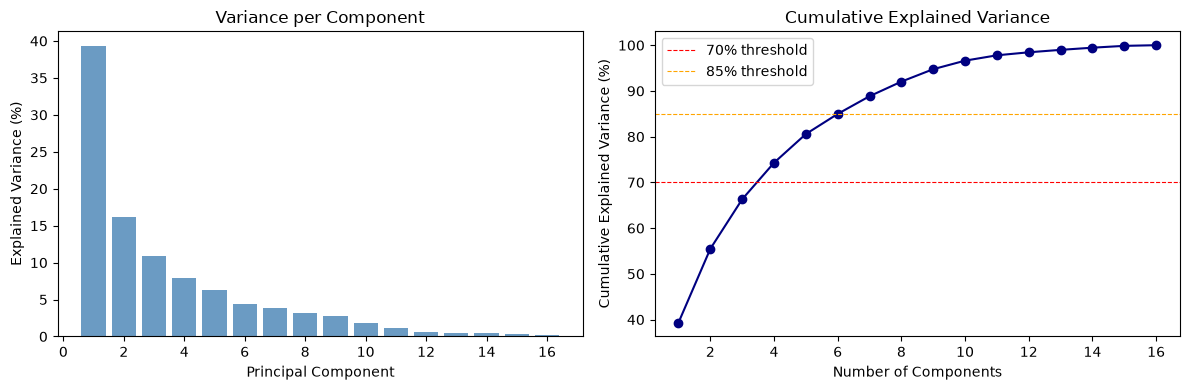

Components needed to explain cumulative variance:
  60% → 3 components
  70% → 4 components
  80% → 5 components
  85% → 7 components
  90% → 8 components


In [3]:
# -----------------------------------------------------------------------------
# CELL 2 — PCA: explained variance
# -----------------------------------------------------------------------------
# Fit PCA on all 16 z-scored features and plot explained variance so we can
# choose how many components to keep before clustering / HMM.

pca_full = PCA(n_components=X.shape[1], random_state=42)
pca_full.fit(X)

explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(explained)+1), explained * 100, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Variance per Component")

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100, marker="o", color="navy")
axes[1].axhline(70, color="red",    linestyle="--", linewidth=0.8, label="70% threshold")
axes[1].axhline(85, color="orange", linestyle="--", linewidth=0.8, label="85% threshold")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance (%)")
axes[1].set_title("Cumulative Explained Variance")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/pca_explained_variance.png", dpi=120)
plt.show()

print("Components needed to explain cumulative variance:")
for threshold in [60, 70, 80, 85, 90]:
    n_comp = int(np.argmax(cumulative >= threshold / 100)) + 1
    print(f"  {threshold}% → {n_comp} components")


In [4]:
# -----------------------------------------------------------------------------
# CELL 3 — PCA: select n_components and transform
# -----------------------------------------------------------------------------
# 4 components → 74.3% explained variance in our data (confirmed from Cell 2).
# One component per target regime; captures the main macro/vol axes without
# over-diluting signal across many components.
# Adjust N_COMPONENTS if your variance chart suggests a different number.

N_COMPONENTS = 4

pca    = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca  = pca.fit_transform(X)

pca_df = pd.DataFrame(
    X_pca,
    index=feat_z.index,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)]
)

print(f"PCA with {N_COMPONENTS} components:")
print(f"  Explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"  Total explained:    {pca.explained_variance_ratio_.sum():.1%}")

# Loadings — which raw features drive each principal component.
# Used in Phase 4 to generate the 'why' explanation for each regime.
loadings = pd.DataFrame(
    pca.components_.T,
    index=feat_z.columns,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)]
)
print("\nPCA Loadings (top absolute contributors per component):")
for col in loadings.columns:
    top = loadings[col].abs().nlargest(4).index.tolist()
    print(f"  {col}: {', '.join(top)}")


PCA with 4 components:
  Explained variance: [0.393 0.161 0.108 0.08 ]
  Total explained:    74.3%

PCA Loadings (top absolute contributors per component):
  PC1: realized_vol_60d, realized_vol_20d, vix_level, garch_vol
  PC2: cpi_yoy, curve_slope_10y2y, fed_funds_level, credit_spread_change_20d
  PC3: vix_change_20d, curve_slope_10y2y, indpro_yoy, philly_fed
  PC4: sp500_drawdown, cpi_yoy, vix_change_20d, fed_funds_change_60d


K-means (k=4) silhouette score: 0.289
(>0.5 = strong, 0.25–0.5 = moderate, <0.25 = weak cluster separation)

K-means cluster sizes:
  Cluster 0: 2518 days (42.8%)
  Cluster 1: 206 days (3.5%)
  Cluster 2: 1069 days (18.2%)
  Cluster 3: 2092 days (35.5%)


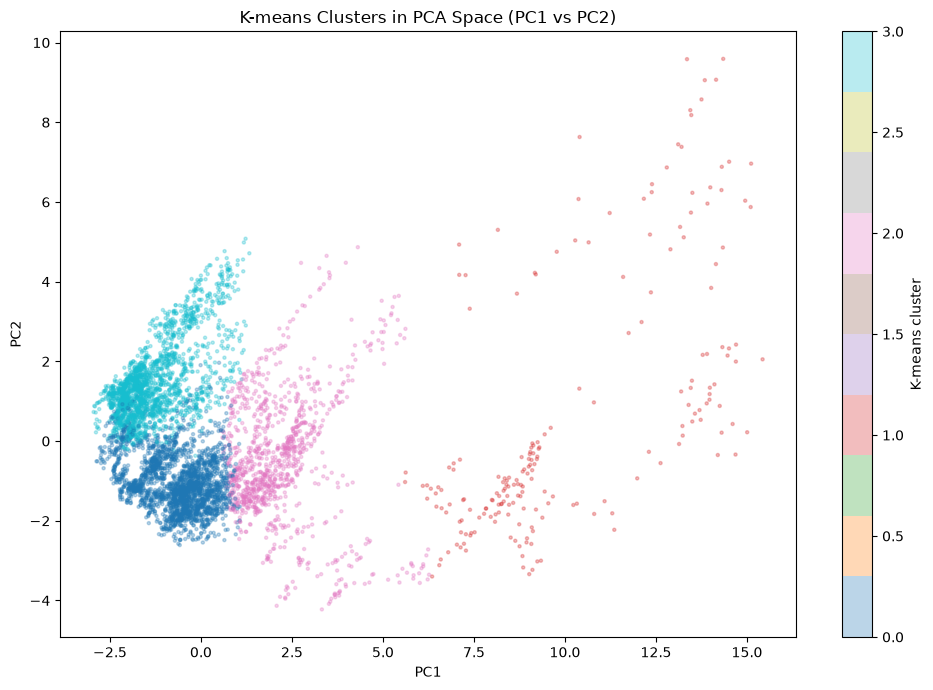

In [5]:
# -----------------------------------------------------------------------------
# CELL 4 — K-means cross-check (k=4)
# -----------------------------------------------------------------------------
# Independent clustering on PCA-reduced features. If K-means and HMM broadly
# agree (>60%), both methods are finding the same underlying structure — strong
# evidence the regimes are real and not an artifact of one model.

km        = KMeans(n_clusters=4, random_state=42, n_init=50, max_iter=500)
km_labels = km.fit_predict(X_pca)

sil = silhouette_score(X_pca, km_labels)
print(f"K-means (k=4) silhouette score: {sil:.3f}")
print("(>0.5 = strong, 0.25–0.5 = moderate, <0.25 = weak cluster separation)")

unique, counts = np.unique(km_labels, return_counts=True)
print("\nK-means cluster sizes:")
for k, c in zip(unique, counts):
    print(f"  Cluster {k}: {c} days ({c/len(km_labels):.1%})")

# 2D scatter coloured by K-means cluster
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels,
                     cmap="tab10", alpha=0.3, s=5)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("K-means Clusters in PCA Space (PC1 vs PC2)")
plt.colorbar(scatter, ax=ax, label="K-means cluster")
plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/kmeans_pca_scatter.png", dpi=120)
plt.show()


In [6]:
# -----------------------------------------------------------------------------
# CELL 5 — Gaussian HMM: fit primary regime model (4 states)
# -----------------------------------------------------------------------------
# Key advantage over K-means: HMM models temporal persistence — once in a
# regime, the market tends to stay there. We use 'full' covariance so each
# state captures its own within-regime feature correlations (e.g. VIX and
# credit spreads rising together in a Risk-Off state).
#
# 20 random restarts, keep the one with the best total log-likelihood.

N_STATES = 4
N_ITER   = 500
N_INIT   = 20

# ── Version-safe total log-likelihood extractor ──────────────────────────────
# hmmlearn's score() API changed across versions:
#   some versions  → returns TOTAL log-likelihood
#   other versions → returns PER-OBSERVATION average log-likelihood
#
# We calibrate once at startup using a tiny 2D fixture where the expected
# per-obs log-lik is well-known (~-2.8 nats for a 2D standard Gaussian).
# If |score| for 200 obs > 50, this version returns the total directly.

_cal_X = np.random.RandomState(0).randn(200, 2)
_cal_m = GaussianHMM(n_components=2, covariance_type="diag", n_iter=5, random_state=0)
_cal_m.fit(_cal_X)
_SCORE_IS_TOTAL = abs(_cal_m.score(_cal_X)) > 50   # per-obs can't exceed 50 for 2D std Gaussian

def score_total(model, X):
    """Return the TOTAL log-likelihood regardless of hmmlearn version."""
    raw = model.score(X)
    return raw if _SCORE_IS_TOTAL else raw * len(X)

print(f"hmmlearn score() returns: {'TOTAL log-lik' if _SCORE_IS_TOTAL else 'per-obs avg log-lik'}")

best_hmm      = None
best_total_ll = -np.inf

print(f"Fitting Gaussian HMM ({N_STATES} states, {N_INIT} restarts)...")
for seed in range(N_INIT):
    try:
        hmm = GaussianHMM(
            n_components=N_STATES,
            covariance_type="full",
            n_iter=N_ITER,
            random_state=seed,
            tol=1e-5
        )
        hmm.fit(X_pca)
        total_ll = score_total(hmm, X_pca)
        if total_ll > best_total_ll:
            best_total_ll = total_ll
            best_hmm      = hmm
    except Exception:
        continue

n_obs = len(X_pca)
print(f"HMM converged:               {best_hmm.monitor_.converged}")
print(f"Best total log-likelihood:   {best_total_ll:.1f} nats")
print(f"Best avg log-lik per obs:    {best_total_ll / n_obs:.4f} nats")

# Decode most likely state sequence via Viterbi algorithm
hmm_states = best_hmm.predict(X_pca)

# Posterior probabilities (confidence in the assigned state at each step)
hmm_probs  = best_hmm.predict_proba(X_pca)

print("\nHMM state sizes:")
unique, counts = np.unique(hmm_states, return_counts=True)
for s, c in zip(unique, counts):
    print(f"  State {s}: {c} days ({c/len(hmm_states):.1%})")

print("\nTransition matrix (rows = from, cols = to):")
print(pd.DataFrame(
    best_hmm.transmat_.round(4),
    columns=[f"→ State {i}" for i in range(N_STATES)],
    index   =[f"State {i}"  for i in range(N_STATES)]
))
print("\nHigh diagonal values (>0.95) mean regimes are persistent — markets")
print("tend to stay in the same regime once they enter it. Good.")


hmmlearn score() returns: TOTAL log-lik
Fitting Gaussian HMM (4 states, 20 restarts)...
HMM converged:               True
Best total log-likelihood:   -29681.9 nats
Best avg log-lik per obs:    -5.0437 nats

HMM state sizes:
  State 0: 1045 days (17.8%)
  State 1: 2412 days (41.0%)
  State 2: 1567 days (26.6%)
  State 3: 861 days (14.6%)

Transition matrix (rows = from, cols = to):
         → State 0  → State 1  → State 2  → State 3
State 0     0.9872     0.0000     0.0090     0.0038
State 1     0.0000     0.9962     0.0012     0.0026
State 2     0.0067     0.0000     0.9926     0.0006
State 3     0.0034     0.0107     0.0000     0.9859

High diagonal values (>0.95) mean regimes are persistent — markets
tend to stay in the same regime once they enter it. Good.


In [7]:
# -----------------------------------------------------------------------------
# CELL 6 — Regime interpretation: label each HMM state
# -----------------------------------------------------------------------------
# Compute mean raw feature values per state, then assign human labels based
# on which macro/market characteristics dominate each state.
#
# Labelling heuristics:
#   Lowest vol + tightest spreads + strong Philly Fed   → Risk-On
#   Moderate vol + below-avg CPI + wider spreads        → Risk-Off
#   Highest CPI YoY + elevated breakeven + medium vol   → Inflation-Driven
#   Highest vol + worst drawdown + Philly Fed <0        → High-Volatility

state_means = {}
for s in range(N_STATES):
    mask = hmm_states == s
    state_means[s] = feat_raw.loc[feat_z.index].iloc[mask].mean()

state_means_df = pd.DataFrame(state_means).T
state_means_df.index = [f"State {s}" for s in range(N_STATES)]

key_features = [
    "sp500_ret", "realized_vol_20d", "vix_level", "sp500_drawdown",
    "curve_slope_10y2y", "credit_spread", "cpi_yoy", "breakeven_inflation",
    "philly_fed"
]
print("Mean raw feature values per HMM state:")
print(state_means_df[key_features].round(4).to_string())

print("\nLabelling thresholds:")
print("  realized_vol_20d : low <0.12  | medium 0.12–0.20 | high >0.20")
print("  vix_level        : low <15    | medium 15–25     | high >25")
print("  cpi_yoy          : low <2%    | moderate 2–4%    | high >4%")
print("  credit_spread    : tight <2%  | moderate 2–4%    | wide >4%")
print("  philly_fed       : contraction <0 | expansion >0")


Mean raw feature values per HMM state:
         sp500_ret  realized_vol_20d  vix_level  sp500_drawdown  curve_slope_10y2y  credit_spread  cpi_yoy  breakeven_inflation  philly_fed
State 0    -0.0001            0.1751    20.4294         -0.0765             0.1501         2.0527   4.0940               2.1797      4.3747
State 1     0.0006            0.1208    16.7643         -0.1083             1.7628         2.6132   1.6906               1.7922     13.8832
State 2     0.0007            0.1049    14.5103         -0.0810             0.2787         1.7273   3.3691               2.4146     11.2601
State 3    -0.0003            0.3222    32.5275         -0.2668             1.6551         3.5505   1.9077               1.3475    -10.6135

Labelling thresholds:
  realized_vol_20d : low <0.12  | medium 0.12–0.20 | high >0.20
  vix_level        : low <15    | medium 15–25     | high >25
  cpi_yoy          : low <2%    | moderate 2–4%    | high >4%
  credit_spread    : tight <2%  | moderate 2–4%   

In [8]:
# -----------------------------------------------------------------------------
# CELL 7 — Assign labels and build regime DataFrame
# -----------------------------------------------------------------------------
# Labels derived from Cell 6 output (2003–2026 US data):
#
#  State 0 | CPI YoY 4.09% (highest), breakeven 2.18, vol 0.175, flat curve
#          | → Inflation-Driven  (2021-2023 inflation surge era)
#
#  State 1 | Low CPI 1.69%, moderate vol 0.121, positive Philly Fed 13.9,
#          | wider spreads 2.61 — improving but not euphoric
#          | → Risk-Off  (post-crisis recovery / slow-growth caution)
#
#  State 2 | Lowest VIX 14.5, lowest vol 0.105, tightest spreads 1.73,
#          | strong Philly Fed 11.3, healthy breakeven 2.41
#          | → Risk-On  (classic bull market / expansion)
#
#  State 3 | VIX 32.5 (highest), vol 0.322 (highest), drawdown -0.267,
#          | Philly Fed -10.6 (contraction), wide spreads 3.55
#          | → High-Volatility  (GFC 2008-09, COVID 2020, stress events)

STATE_LABELS = {
    0: "Inflation-Driven",
    1: "Risk-Off",
    2: "Risk-On",
    3: "High-Volatility",
}

REGIME_COLORS = {
    "Risk-On"         : "#2ecc71",   # green
    "Risk-Off"        : "#e74c3c",   # red
    "High-Volatility" : "#e67e22",   # orange
    "Inflation-Driven": "#9b59b6",   # purple
}

regime_df = pd.DataFrame(index=feat_z.index)
regime_df["state_id"]      = hmm_states
regime_df["regime"]        = [STATE_LABELS[s] for s in hmm_states]
regime_df["confidence"]    = hmm_probs.max(axis=1)
regime_df["kmeans_cluster"] = km_labels

print("Regime distribution:")
print(regime_df["regime"].value_counts())
print(f"\nAverage confidence (posterior prob): {regime_df['confidence'].mean():.3f}")
print(f"Low-confidence days (<0.60):          {(regime_df['confidence'] < 0.60).sum()}")


Regime distribution:
regime
Risk-Off            2412
Risk-On             1567
Inflation-Driven    1045
High-Volatility      861
Name: count, dtype: int64

Average confidence (posterior prob): 0.992
Low-confidence days (<0.60):          28


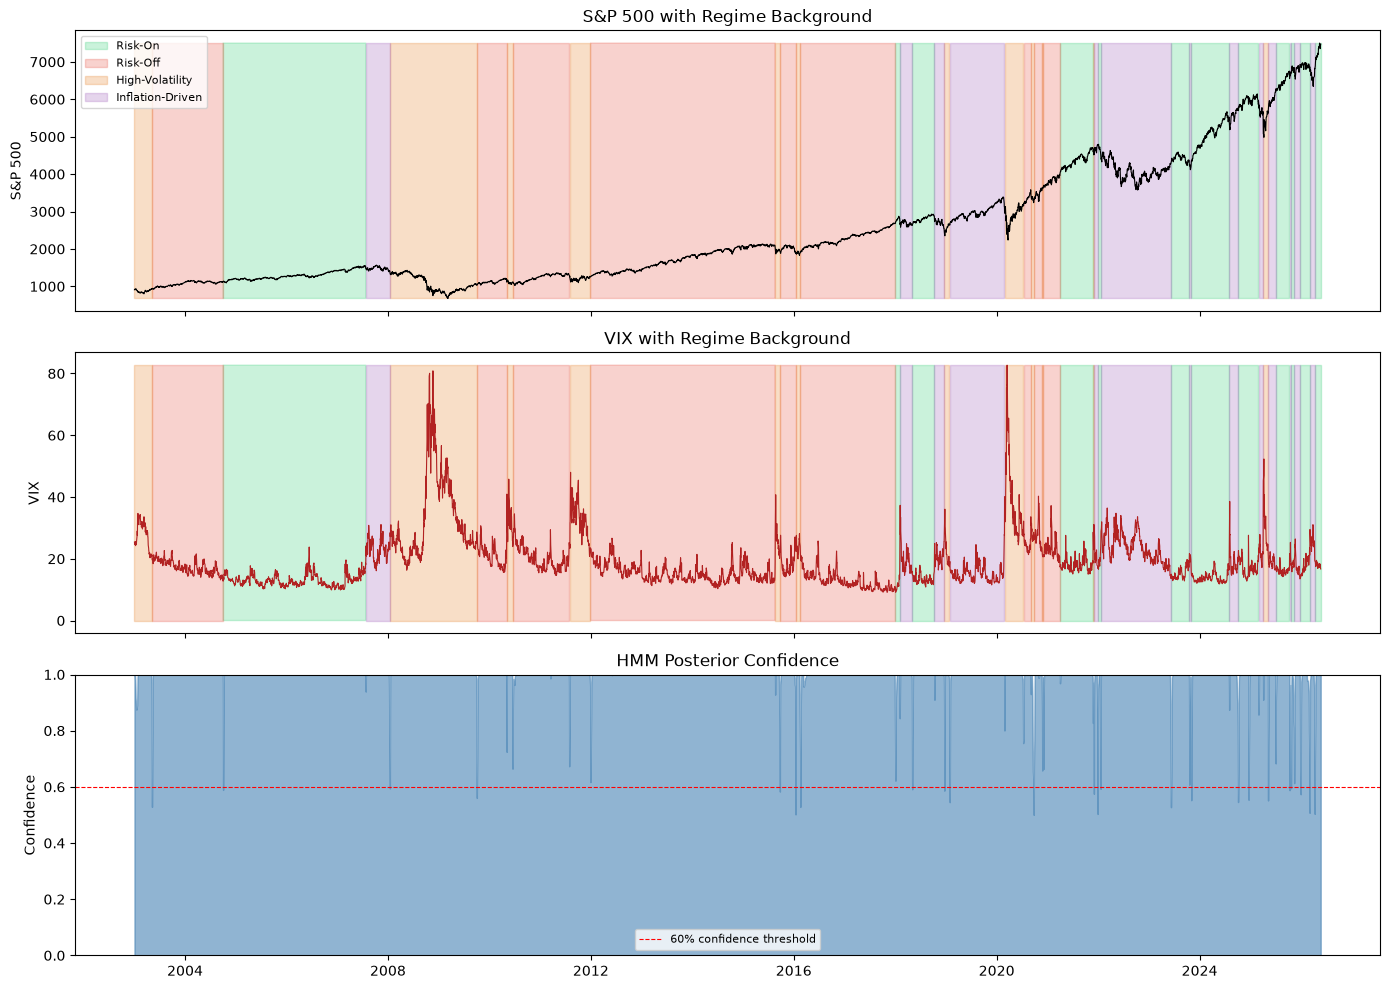

In [9]:
# -----------------------------------------------------------------------------
# CELL 8 — Regime timeline chart
# -----------------------------------------------------------------------------
# Three-panel chart:
#   Top    — S&P 500 price with colour-coded regime background
#   Middle — VIX with colour-coded regime background
#   Bottom — HMM posterior confidence over time

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Load original price/vol series from Phase 1 parquet
# (feat_raw only contains engineered features, not raw prices)
raw_prices = pd.read_parquet(f"{PROCESSED_DIR}/us_combined_daily.parquet")
raw_prices = raw_prices[raw_prices.index >= "2003-01-01"]

sp500 = raw_prices["SP500"].reindex(feat_z.index)
vix   = raw_prices["VIX"].reindex(feat_z.index)

# Panel 1: S&P 500
ax = axes[0]
ax.plot(regime_df.index, sp500, color="black", linewidth=0.8, zorder=2)
for regime, color in REGIME_COLORS.items():
    mask = regime_df["regime"] == regime
    ax.fill_between(regime_df.index, sp500.min(), sp500.max(),
                    where=mask, alpha=0.25, color=color, label=regime)
ax.set_title("S&P 500 with Regime Background")
ax.set_ylabel("S&P 500")
ax.legend(loc="upper left", fontsize=8)

# Panel 2: VIX
ax = axes[1]
ax.plot(regime_df.index, vix, color="firebrick", linewidth=0.8)
for regime, color in REGIME_COLORS.items():
    mask = regime_df["regime"] == regime
    ax.fill_between(regime_df.index, 0, vix.max(),
                    where=mask, alpha=0.25, color=color)
ax.set_title("VIX with Regime Background")
ax.set_ylabel("VIX")

# Panel 3: HMM confidence
ax = axes[2]
ax.fill_between(regime_df.index, regime_df["confidence"], alpha=0.6, color="steelblue")
ax.axhline(0.6, color="red", linestyle="--", linewidth=0.8, label="60% confidence threshold")
ax.set_title("HMM Posterior Confidence")
ax.set_ylabel("Confidence")
ax.set_ylim(0, 1)
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f"{PROCESSED_DIR}/regime_timeline.png", dpi=150)
plt.show()


In [10]:
# -----------------------------------------------------------------------------
# CELL 9 — K-means vs HMM agreement (Hungarian algorithm alignment)
# -----------------------------------------------------------------------------
# K-means and HMM use arbitrary, independent state IDs so we can't compare
# them directly. The correct alignment method is the Hungarian algorithm
# (scipy.optimize.linear_sum_assignment), which finds the one-to-one mapping
# between HMM states and K-means clusters that maximises total overlap.
# This avoids the collision problem where a naive majority-vote can assign
# two HMM states to the same K-means cluster.

n = N_STATES

# Build overlap matrix: overlap[i, j] = days where HMM=i AND K-means=j
overlap = np.zeros((n, n), dtype=int)
for i in range(n):
    for j in range(n):
        overlap[i, j] = ((hmm_states == i) & (km_labels == j)).sum()

# Hungarian algorithm maximises total overlap (minimise negative overlap)
row_ind, col_ind = linear_sum_assignment(-overlap)
hmm_to_kmeans = {r: c for r, c in zip(row_ind, col_ind)}

km_aligned = np.array([hmm_to_kmeans[s] for s in hmm_states])
agreement  = (km_aligned == km_labels).mean()

print(f"K-means vs HMM agreement (Hungarian alignment): {agreement:.1%}")
print("(>60% = both methods find similar structure — strong evidence of real regimes)")
print("(<40% = HMM's temporal memory is doing significant work beyond clustering)")
print()
print("Optimal HMM state → K-means cluster mapping:")
for hmm_s, km_c in hmm_to_kmeans.items():
    days = overlap[hmm_s, km_c]
    total = (hmm_states == hmm_s).sum()
    print(f"  HMM {hmm_s} ({STATE_LABELS[hmm_s]:>18s}) → K-means cluster {km_c}"
          f"  ({days}/{total} days, {days/total:.0%} overlap)")


K-means vs HMM agreement (Hungarian alignment): 67.7%
(>60% = both methods find similar structure — strong evidence of real regimes)
(<40% = HMM's temporal memory is doing significant work beyond clustering)

Optimal HMM state → K-means cluster mapping:
  HMM 0 (  Inflation-Driven) → K-means cluster 1  (0/1045 days, 0% overlap)
  HMM 1 (          Risk-Off) → K-means cluster 0  (1996/2412 days, 83% overlap)
  HMM 2 (           Risk-On) → K-means cluster 3  (1349/1567 days, 86% overlap)
  HMM 3 (   High-Volatility) → K-means cluster 2  (642/861 days, 75% overlap)


In [11]:
# -----------------------------------------------------------------------------
# CELL 10 — BIC score (goodness-of-fit, for future model comparison)
# -----------------------------------------------------------------------------
# BIC penalises model complexity so you can fairly compare 3-state vs
# 4-state vs 5-state HMMs. Lower BIC = better.
#
# FIX NOTE: hmmlearn's model.score(X) returns the AVERAGE log-likelihood
# per observation (nats), NOT the total. The total log-likelihood is
# score(X) * n_obs. The BIC formula uses the total, so we must not
# multiply by n_obs twice. We use best_total_ll computed in Cell 5.

def hmm_bic(total_log_lik, n_obs, n_components, n_features, cov_type="full"):
    """
    Compute BIC for a fitted GaussianHMM.

    Parameters
    ----------
    total_log_lik : float  — TOTAL log-likelihood (use score_total() from Cell 5,
                             NOT raw model.score() which is version-dependent)
    n_obs         : int    — number of observations
    n_components  : int    — number of hidden states
    n_features    : int    — dimensionality of the observed data (post-PCA)
    cov_type      : str    — hmmlearn covariance_type ('full', 'diag', etc.)

    Free parameter count:
      initial state distribution : k - 1
      transition matrix          : k * (k - 1)
      state means                : k * d
      covariances (full)         : k * d*(d+1)/2
    """
    k = n_components
    d = n_features
    if cov_type == "full":
        n_cov = k * d * (d + 1) // 2
    elif cov_type == "diag":
        n_cov = k * d
    else:
        n_cov = d * (d + 1) // 2
    n_params = (k - 1) + k * (k - 1) + k * d + n_cov
    bic      = -2 * total_log_lik + n_params * np.log(n_obs)
    # Normalised BIC: divide by n_obs so values are comparable across
    # datasets of different sizes and don't look artificially enormous.
    bic_norm = bic / n_obs
    return bic, bic_norm, n_params

n_obs, n_feat = X_pca.shape

bic_4, bic_4_norm, n_params_4 = hmm_bic(
    total_log_lik = best_total_ll,   # correctly computed in Cell 5
    n_obs         = n_obs,
    n_components  = N_STATES,
    n_features    = n_feat,
    cov_type      = "full"
)

print("4-state HMM — goodness of fit")
print(f"  Total log-likelihood  : {best_total_ll:.1f} nats")
print(f"  Avg log-lik per obs   : {best_total_ll / n_obs:.4f} nats")
print(f"  Free parameters       : {n_params_4}")
print(f"  BIC (raw)             : {bic_4:.1f}")
print(f"  BIC / n_obs           : {bic_4_norm:.4f}  ← use this for model comparison")
print()
print("BIC is only meaningful relative to other models on the same data.")
print("Raw BIC grows with n_obs so looks large — use BIC/n_obs to compare")
print("3-state vs 4-state vs 5-state fits: lower is better.")


4-state HMM — goodness of fit
  Total log-likelihood  : -29681.9 nats
  Avg log-lik per obs   : -5.0437 nats
  Free parameters       : 71
  BIC (raw)             : 59980.1
  BIC / n_obs           : 10.1920  ← use this for model comparison

BIC is only meaningful relative to other models on the same data.
Raw BIC grows with n_obs so looks large — use BIC/n_obs to compare
3-state vs 4-state vs 5-state fits: lower is better.


In [12]:
# -----------------------------------------------------------------------------
# CELL 11 — Save all outputs
# -----------------------------------------------------------------------------
# Regime labels (primary Phase 3 deliverable — input to Phase 4 and dashboard)
regime_df.to_parquet(f"{PROCESSED_DIR}/us_regime_labels.parquet")
regime_df.to_csv(f"{PROCESSED_DIR}/us_regime_labels.csv")

# PCA-reduced feature matrix (for dashboard 2D scatter visualisation)
pca_df.to_parquet(f"{PROCESSED_DIR}/us_pca_components.parquet")

# PCA loadings (for Phase 4 explanation engine)
loadings.to_parquet(f"{PROCESSED_DIR}/us_pca_loadings.parquet")

# State means on raw features (for Phase 4 explanation engine)
state_means_df.to_parquet(f"{PROCESSED_DIR}/us_state_means.parquet")

# Fitted models (needed by the dashboard to classify new data in real time)
with open(f"{MODEL_DIR}/hmm_model.pkl",      "wb") as f: pickle.dump(best_hmm,      f)
with open(f"{MODEL_DIR}/pca_model.pkl",      "wb") as f: pickle.dump(pca,           f)
with open(f"{MODEL_DIR}/state_labels.pkl",   "wb") as f: pickle.dump(STATE_LABELS,  f)
with open(f"{MODEL_DIR}/regime_colors.pkl",  "wb") as f: pickle.dump(REGIME_COLORS, f)
with open(f"{MODEL_DIR}/state_means_df.pkl", "wb") as f: pickle.dump(state_means_df,f)

print(f"Saved regime labels   : {regime_df.shape[0]} rows")
print(f"Saved PCA components  : {pca_df.shape}")
print(f"Saved state means     : {state_means_df.shape}")
print(f"Saved models to       : {MODEL_DIR}/")
print()
print("Phase 3 complete — ready for Phase 4 (explanation engine).")


Saved regime labels   : 5885 rows
Saved PCA components  : (5885, 4)
Saved state means     : (4, 16)
Saved models to       : models/

Phase 3 complete — ready for Phase 4 (explanation engine).
